# Aula 4 - Mais Pandas

Nessa aula, iremos tratar dos seguintes conteúdos:
- Pandas
- Series
- Métodos Pandas
- DataFrames
- Combinando DataFrames
- Trabalhando com CSVs
- GroupBy e Agregadores

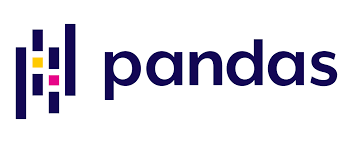

##   

## Pandas

__Pandas__ é um pacote python construído com base no __NumPy__ e __Matplotlib__ que busca organizar dados no formato de tabela, atribuindo rótulos às linhas e colunas. O pacote __Pandas__ fornece ainda um conjunto de funcionalidades que permite processar as informações de tabelas de forma bastante eficiente, implementando métodos fundamentais para fins de tratamento de dados.

O Pandas organiza os dados nos seguintes tipos de estruturas:
- Series (Séries)
- DataFrame

## Combinando DataFrames
__Pandas__ fornece um conjunto de métodos para combinar DataFrames, o que é extremamente útil em cenários envolvendo múltiplas fontes de dados. Em particular, os métodos:
- __merge__ combina DataFrames com base nos rótulos das linhas ou valores das colunas
- __concatenate__ combina DataFrames a partir de um eixo específico

### merge
O método __merge__ "funde" dois DataFrames, duas séries, ou uma série com um DataFrame.

A fuzão pode ser feita com base nos:
- valores de duas colunas específicas, uma em cada DataFrame 
- valores de uma coluna em um dos DataFrame e rótulos das linhas no outro
- valores dos rótulos das linhas em ambos os DataFrames (ou Séries)

#### Merge baseado nos valores de duas colunas

In [1]:
import pandas as pd 

In [8]:
# Construindo dois DataFrames que serão fundidos com o método 'merge'
df1 = pd.DataFrame({'key': ['b','b','a','c','a','a','b'], 
                   'data1': range(7)})

df2 = pd.DataFrame({'key': ['a','b','d'], 
                   'data2': range(3)})

# Print do primeiro Dataframe
print("df1")
display(df1)

# Print do Segundo Dataframe
print("df2")
display(df2)

df1


,key,data1
0,b,0
1,b,1
2,a,2
3,c,3
4,a,4
5,a,5
6,b,6


df2


,key,data2
0,a,0
1,b,1
2,d,2


In [4]:
# SELECT 
#     d1.key, 
#     d1.data1,
#     d2.data2
# FROM
# df1 AS d1 
# LEFT JOIN df2 as d2 
# ON d1.key = d2.key

In [9]:
pd.merge(df1, df2, on = "key", how = "left")

,key,data1,data2
0,b,0,1.0
1,b,1,1.0
2,a,2,0.0
3,c,3,NaN
4,a,4,0.0
5,a,5,0.0
6,b,6,1.0


In [6]:
df1.merge(df2, on ="key", how = "left")

,key,data1,data2
0,b,0,1.0
1,b,0,3.0
2,b,1,1.0
3,b,1,3.0
4,a,2,0.0
5,c,3,NaN
6,a,4,0.0
7,a,5,0.0
8,b,6,1.0
9,b,6,3.0


In [10]:
df1.merge(df2, left_on = "key", right_on = "key", how = "left")

,key,data1,data2
0,b,0,1.0
1,b,1,1.0
2,a,2,0.0
3,c,3,NaN
4,a,4,0.0
5,a,5,0.0
6,b,6,1.0


In [11]:
df1.merge(df2, on = "key", how = "inner")

,key,data1,data2
0,b,0,1
1,b,1,1
2,a,2,0
3,a,4,0
4,a,5,0
5,b,6,1


In [15]:
df1_mergeado = df1.merge(df2, on = "key", how = "outer")
df1_mergeado

,key,data1,data2
0,a,2.0,0.0
1,a,4.0,0.0
2,a,5.0,0.0
3,b,0.0,1.0
4,b,1.0,1.0
5,b,6.0,1.0
6,c,3.0,NaN
7,d,NaN,2.0


In [17]:
df1_mergeado

,key,data1,data2
0,a,2.0,0.0
1,a,4.0,0.0
2,a,5.0,0.0
3,b,0.0,1.0
4,b,1.0,1.0
5,b,6.0,1.0
6,c,3.0,NaN
7,d,NaN,2.0


# Para casa: 

Faça o left join da tabela df2 com a tabela df1

In [18]:
df2.merge(df1, on = "key", how = 'left')

,key,data2,data1
0,a,0,2.0
1,a,0,4.0
2,a,0,5.0
3,b,1,0.0
4,b,1,1.0
5,b,1,6.0
6,d,2,NaN


In [19]:
df1.merge(df2, on = "key", how = "right")

,key,data1,data2
0,a,2.0,0
1,a,4.0,0
2,a,5.0,0
3,b,0.0,1
4,b,1.0,1
5,b,6.0,1
6,d,NaN,2


### concat
O método __concat__ é utilizado para juntar DataFrames ou Séries com base em um dos eixos.
- __axis = 0__ concatena por linhas 
- __axis = 1__ concatena por colunas. Quando empregado em um conjunto de séries resulta em um DataFrame

O método assume como parâmetro uma lista de DataFrames ou Séries.

In [22]:
pd.concat([df1, df2], axis = 1)

,key,data1,key,data2
0,b,0,a,0.0
1,b,1,b,1.0
2,a,2,d,2.0
3,c,3,NaN,NaN
4,a,4,NaN,NaN
5,a,5,NaN,NaN
6,b,6,NaN,NaN


In [23]:
pd.concat([df1, df2], axis = 0)

,key,data1,data2
0,b,0.0,NaN
1,b,1.0,NaN
2,a,2.0,NaN
3,c,3.0,NaN
4,a,4.0,NaN
5,a,5.0,NaN
6,b,6.0,NaN
0,a,NaN,0.0
1,b,NaN,1.0
2,d,NaN,2.0


##   

## Trabalhando com CSVs

O __Pandas__ tem algumas funcionalidades bem interessantes, como por exemplo permitir que carregue para o Notebook arquivos no formato csv, excel, xlsx e etc. Vamos ver uma aplicação como o CSV:

In [27]:
# Carrega um arquivo CSV
df = pd.read_csv('titanic.csv')
print(df.shape)
# Print do DataFrame
df.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [29]:
# df[df["Fare"] == 0]
df.query('Fare == 0')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
179,180,0,3,"Leonard, Mr. Lionel",male,36.0,0,0,LINE,0.0,NaN,S
263,264,0,1,"Harrison, Mr. William",male,40.0,0,0,112059,0.0,B94,S
271,272,1,3,"Tornquist, Mr. William Henry",male,25.0,0,0,LINE,0.0,NaN,S
277,278,0,2,"Parkes, Mr. Francis ""Frank""",male,NaN,0,0,239853,0.0,NaN,S
302,303,0,3,"Johnson, Mr. William Cahoone Jr",male,19.0,0,0,LINE,0.0,NaN,S
413,414,0,2,"Cunningham, Mr. Alfred Fleming",male,NaN,0,0,239853,0.0,NaN,S
466,467,0,2,"Campbell, Mr. William",male,NaN,0,0,239853,0.0,NaN,S
481,482,0,2,"Frost, Mr. Anthony Wood ""Archie""",male,NaN,0,0,239854,0.0,NaN,S
597,598,0,3,"Johnson, Mr. Alfred",male,49.0,0,0,LINE,0.0,NaN,S
633,634,0,1,"Parr, Mr. William Henry Marsh",male,NaN,0,0,112052,0.0,NaN,S


In [ ]:
#df.to_csv('titanic_alterado.csv')

[Neste Link](https://www.kaggle.com/c/titanic/data), conseguimos mais informações sobre a base de dados do Titanic! O Kaggle é uma plataforma muito conheciida no quesito de competições de Data Science e Machine Learning, além de disponibilizar diversos conjuntos de dados para treinarmos =)

Vamos testar alguns outros __métodos__ disponíveis para os DaataFrames:

##    

## GroupBy e Agregadores

Podemos utilizar o __GroupBy__, para fsazer alguns cálculos de agrupamentos específicos (bem parecido com o que fazemos no SQL):

In [33]:
# Calcula a média de Idade por Sexo
## para agruparmos usamos o metodo group by
## no parentesis passamos uma coluna ou um conjunto de colunas
## Depois precisamos passar entre colchetes o campo que vamos agrupar
## Por fim passamos a metrica que quermos

df.groupby("Sex")["Age"].mean()

Sex
female    27.915709
male      30.726645
Name: Age, dtype: float64

In [ ]:
# SELECT 
#     Sex,
#     AVG(Age)
# FROM df 
# GROUP BY Sex

Pode-se também calcular mais de uma métrica por vez utilizando o __GroupBy__ combinado com o método __agg:__

In [35]:
# Calculo das Métricas para o Agrupamento Sexo e Idade
# Quero calcular muitas metricas na mesma linha
# podemos usar o .agg e passar uma lista de metricas

df.groupby("Sex")["Age"].agg(["mean",'std',"count"])

,mean,std,count
Sex,,,
female,27.915709,14.110146,261
male,30.726645,14.678201,453


In [38]:
# Com mais de uma categoria dentro do Groupby
# Quero ter mais de uma categoria
# Podemos passar no parentesis uma lista de colunas também

df.groupby(["Sex", "Pclass"])["Age"].agg(["mean","std","count"])

mean        std  count
Sex    Pclass                             
female 1       34.611765  13.612052     85
       2       28.722973  12.872702     74
       3       21.750000  12.729964    102
male   1       41.281386  15.139570    101
       2       30.740707  14.793894     99
       3       26.507589  12.159514    253

In [41]:
# Mais de uma categoria e mais de uma métrica calculando
# Podemos calcular para um conjunto de dados diferentes as metricas
# basta passar no indexador (no colchete) uma lista de colunas

df.groupby(["Sex","Pclass"])[   ["Age", "Fare"]     ].agg(["mean", "std", "count"])

Age                         Fare                 
                    mean        std count        mean        std count
Sex    Pclass                                                         
female 1       34.611765  13.612052    85  106.125798  74.259988    94
       2       28.722973  12.872702    74   21.970121  10.891796    76
       3       21.750000  12.729964   102   16.118810  11.690314   144
male   1       41.281386  15.139570   101   67.226127  77.548021   122
       2       30.740707  14.793894    99   19.741782  14.922235   108
       3       26.507589  12.159514   253   12.661633  11.681696   347

In [42]:
df.groupby(["Sex", "Pclass"]).agg(
                                    {
                                        "Age" : ["mean","std","count"],
                                        "Fare": ["mean"]
                                    })

Age                         Fare
                    mean        std count        mean
Sex    Pclass                                        
female 1       34.611765  13.612052    85  106.125798
       2       28.722973  12.872702    74   21.970121
       3       21.750000  12.729964   102   16.118810
male   1       41.281386  15.139570   101   67.226127
       2       30.740707  14.793894    99   19.741782
       3       26.507589  12.159514   253   12.661633

In [47]:
df_grp = df.groupby(["Sex", "Pclass"]).agg(
                                    {
                                        "Age" : ["mean","std","count"],
                                        "Fare": ["mean"]
                                    })
df_grp

Age                         Fare
                    mean        std count        mean
Sex    Pclass                                        
female 1       34.611765  13.612052    85  106.125798
       2       28.722973  12.872702    74   21.970121
       3       21.750000  12.729964   102   16.118810
male   1       41.281386  15.139570   101   67.226127
       2       30.740707  14.793894    99   19.741782
       3       26.507589  12.159514   253   12.661633

In [57]:
df_grp_reseted = df_grp.reset_index()
df_grp_reseted

Sex Pclass        Age                         Fare
                       mean        std count        mean
0  female      1  34.611765  13.612052    85  106.125798
1  female      2  28.722973  12.872702    74   21.970121
2  female      3  21.750000  12.729964   102   16.118810
3    male      1  41.281386  15.139570   101   67.226127
4    male      2  30.740707  14.793894    99   19.741782
5    male      3  26.507589  12.159514   253   12.661633

In [59]:
df_grp_reseted.columns

MultiIndex([(   'Sex',      ''),
            ('Pclass',      ''),
            (   'Age',  'mean'),
            (   'Age',   'std'),
            (   'Age', 'count'),
            (  'Fare',  'mean')],
           )

In [60]:
df_grp_reseted.columns = ["Sex","Pclass","Age_mean","Age_std","Age_count", "Fare_mean"]

In [63]:
df_grp_reseted.rename(
    columns = {
        "Age_mean": "média idade",
        "Age_std": "dp idade",
        "Age_count": "contagem",
        "Fare_mean": "preço médio"
    }
)

,Sex,Pclass,média idade,dp idade,contagem,preço médio
0,female,1,34.611765,13.612052,85,106.125798
1,female,2,28.722973,12.872702,74,21.970121
2,female,3,21.750000,12.729964,102,16.118810
3,male,1,41.281386,15.139570,101,67.226127
4,male,2,30.740707,14.793894,99,19.741782
5,male,3,26.507589,12.159514,253,12.661633


In [64]:
df_grp_reseted

,Sex,Pclass,Age_mean,Age_std,Age_count,Fare_mean
0,female,1,34.611765,13.612052,85,106.125798
1,female,2,28.722973,12.872702,74,21.970121
2,female,3,21.750000,12.729964,102,16.118810
3,male,1,41.281386,15.139570,101,67.226127
4,male,2,30.740707,14.793894,99,19.741782
5,male,3,26.507589,12.159514,253,12.661633


In [65]:
df_grp_reseted.rename(
    columns = {
        "Age_mean": "média idade",
        "Age_std": "dp idade",
        "Age_count": "contagem",
        "Fare_mean": "preço médio"
    },
    inplace = True
)

In [66]:
df_grp_reseted

,Sex,Pclass,média idade,dp idade,contagem,preço médio
0,female,1,34.611765,13.612052,85,106.125798
1,female,2,28.722973,12.872702,74,21.970121
2,female,3,21.750000,12.729964,102,16.118810
3,male,1,41.281386,15.139570,101,67.226127
4,male,2,30.740707,14.793894,99,19.741782
5,male,3,26.507589,12.159514,253,12.661633


## Exercícios

### Para o Dataframe do Titanic

**1)** Faça a leitura do Dataframe e mostre as 5 primeiras linhas

In [67]:
df = pd.read_csv('titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**2)** Calcule a tarifa média por Sexo

In [68]:
df.groupby('Sex')['Fare'].mean()

Sex
female    44.479818
male      25.523893
Name: Fare, dtype: float64

**3)** Determine o passageiro que pagou a maior tarifa

In [69]:
df[df['Fare'] == df['Fare'].max()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C


**4)** Determine a idade média dos sobreviventes

In [70]:
df.groupby(['Survived'])['Age'].mean()

Survived
0    30.626179
1    28.343690
Name: Age, dtype: float64

In [71]:
df[df['Survived'] == 1]['Age'].mean()

28.343689655172415

##  

## Links, Artigos e Referências:

- [Documentação do Pandas](https://pandas.pydata.org/docs/), documentação onde vocês podem encontrar mais informações sobre os métodos e funções do Pandas e descobrir novos métodos que não foram apresentados no curso;
- ["10 Python Pandas Tricks that make your work more efficient",](https://towardsdatascience.com/10-python-pandas-tricks-that-make-your-work-more-efficient-2e8e483808ba) artigo escrito pelo Towards Data Science;
- ["28 useful Pandas functions you might not know"](https://paulovasconcellos.com.br/28-useful-pandas-functions-you-might-not-know-de42c59db085https://medium.com/@zachary.bedell/writing-beautiful-code-with-numpy-505f3b353174), artigo escrito por Paulo Vasconcellos para o Data Hackers;

# Vamos fazer uma análise?

In [72]:
import seaborn as sns 

penguins = sns.load_dataset("penguins")
print(penguins.shape)
penguins.head()

(344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [73]:
penguins.to_csv("meu_penguins_datset.csv", index = False)

In [79]:
penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [80]:
penguins.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [84]:
penguins["sex"].value_counts(normalize= True)

sex
Male      0.504505
Female    0.495495
Name: proportion, dtype: float64

In [85]:
penguins["sex"].value_counts(normalize= True, dropna = False)

sex
Male      0.488372
Female    0.479651
NaN       0.031977
Name: proportion, dtype: float64

In [88]:
penguins[penguins["flipper_length_mm"].isnull()]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN


In [ ]:
# média com preenchimento de nulos
penguins['flipper_length_mm'].fillna(0).mean()

199.74709302325581

In [ ]:
# média sem preenchimento de nulos
penguins['flipper_length_mm'].mean()

200.91520467836258

In [92]:
media = penguins["flipper_length_mm"].mean()

penguins['flipper_length_mm'].fillna(media).mean()

200.91520467836258

In [97]:
(penguins.isnull().sum() / penguins.shape[0]).mul(100).round(2).astype(str) + " %"

species               0.0 %
island                0.0 %
bill_length_mm       0.58 %
bill_depth_mm        0.58 %
flipper_length_mm    0.58 %
body_mass_g          0.58 %
sex                   3.2 %
dtype: object

In [98]:
penguins.dropna()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [101]:
penguins_filtrados = penguins[['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g']]

In [ ]:
penguins_filtrados.isnull().sum()

species              0
island               0
bill_length_mm       2
bill_depth_mm        2
flipper_length_mm    2
body_mass_g          2
dtype: int64

In [104]:
penguins_filtrados.dropna()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0
...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0


In [108]:
penguins_2 = penguins.dropna().reset_index(drop = True)
penguins_2.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


In [109]:
# média de peso por espécie 
penguins_2.groupby("species")["body_mass_g"].mean()

species
Adelie       3706.164384
Chinstrap    3733.088235
Gentoo       5092.436975
Name: body_mass_g, dtype: float64

In [111]:
# média de peso por ilha 
penguins_2.groupby("island")["body_mass_g"].mean()

island
Biscoe       4719.171779
Dream        3718.902439
Torgersen    3708.510638
Name: body_mass_g, dtype: float64

In [144]:
penguins_2.groupby("island")["body_mass_g"].sum()

island
Biscoe       769225.0
Dream        457425.0
Torgersen    174300.0
Name: body_mass_g, dtype: float64

In [113]:
penguins_2.groupby(["island", "species"])["body_mass_g"].mean()

island     species  
Biscoe     Adelie       3709.659091
           Gentoo       5092.436975
Dream      Adelie       3701.363636
           Chinstrap    3733.088235
Torgersen  Adelie       3708.510638
Name: body_mass_g, dtype: float64

In [115]:
penguins_2.groupby(["island", "species"])["body_mass_g"].agg(["mean", 'count'])

mean  count
island    species                      
Biscoe    Adelie     3709.659091     44
          Gentoo     5092.436975    119
Dream     Adelie     3701.363636     55
          Chinstrap  3733.088235     68
Torgersen Adelie     3708.510638     47

In [116]:
penguins_2["sex"].value_counts()

sex
Male      168
Female    165
Name: count, dtype: int64

In [117]:
penguins_2["sex"].value_counts().reset_index()

,sex,count
0,Male,168
1,Female,165


<Axes: >

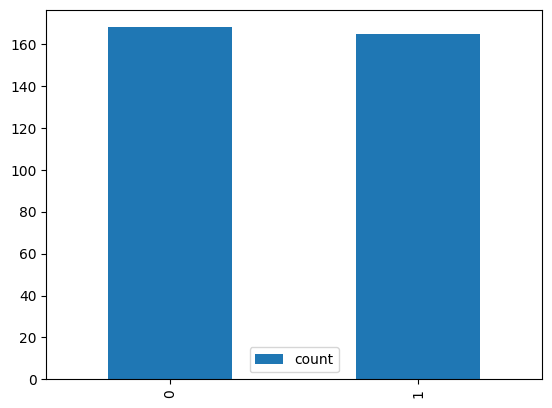

In [118]:
penguins_2["sex"].value_counts().reset_index().plot(kind = "bar")

<Axes: >

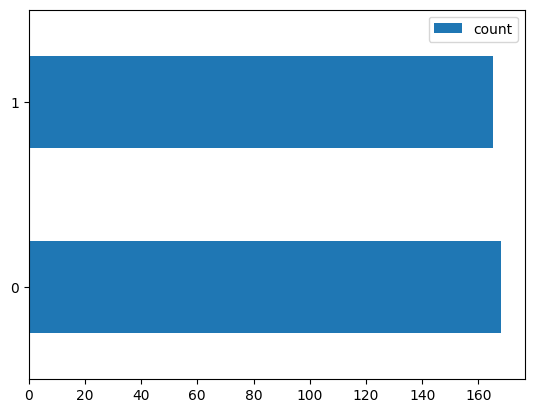

In [119]:
penguins_2["sex"].value_counts().reset_index().plot(kind = "barh")

<Axes: title={'center': 'Bicos'}, xlabel='bill_length_mm', ylabel='bill_depth_mm'>

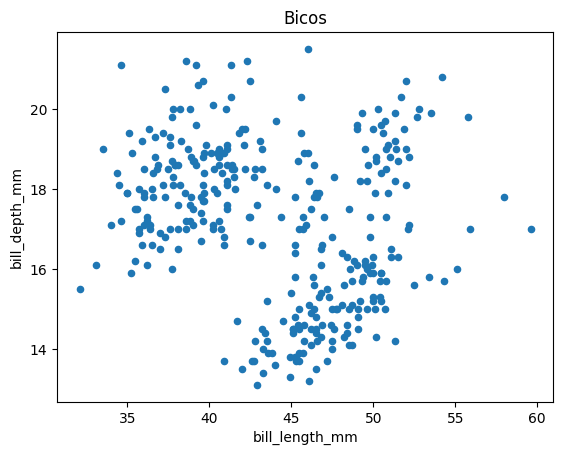

In [122]:
penguins_2.plot(x = "bill_length_mm", y = "bill_depth_mm", kind = "scatter", title = "Bicos")

<Axes: title={'center': 'Bicos Machos'}, xlabel='bill_length_mm', ylabel='bill_depth_mm'>

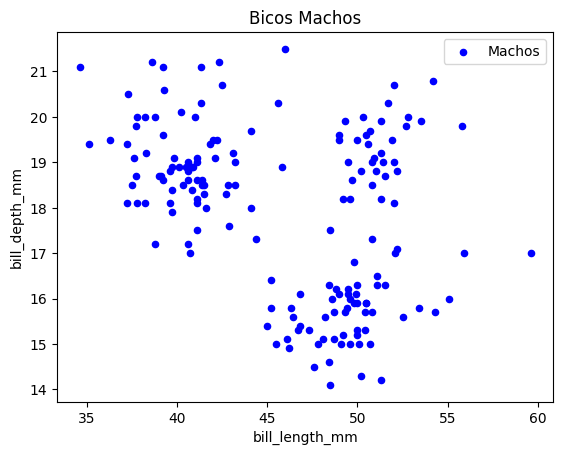

In [125]:
penguins_2[penguins_2["sex"] == "Male"].plot(
    x = "bill_length_mm",
    y = "bill_depth_mm",
    kind = "scatter",
    title = "Bicos Machos",
    color = "blue",
    label = "Machos"
)

<Axes: title={'center': 'Bicos Fêmeas'}, xlabel='bill_length_mm', ylabel='bill_depth_mm'>

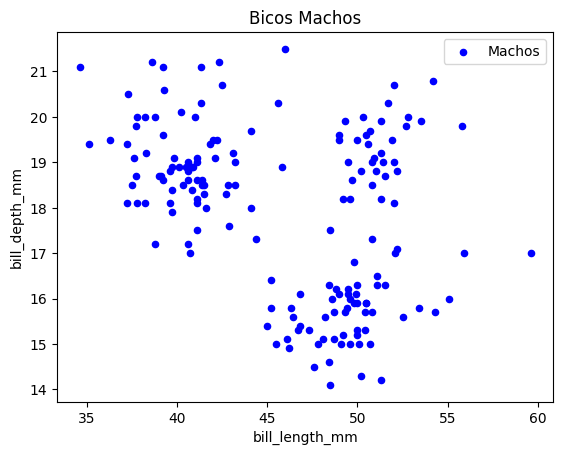

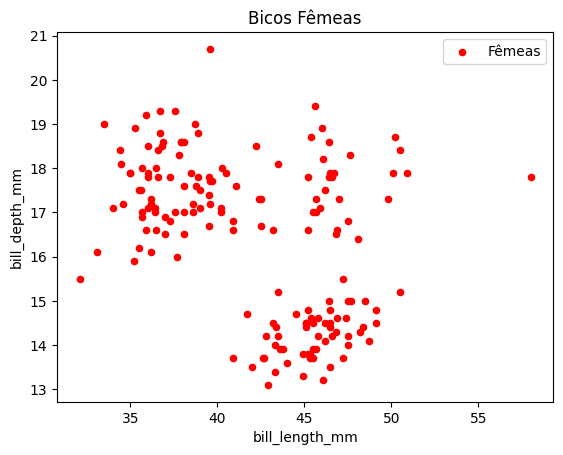

In [126]:
ax1 = penguins_2[penguins_2["sex"] == "Male"].plot(
    x = "bill_length_mm",
    y = "bill_depth_mm",
    kind = "scatter",
    title = "Bicos Machos",
    color = "blue",
    label = "Machos"
)

penguins_2[penguins_2["sex"] == "Female"].plot(
    x = "bill_length_mm", 
    y = "bill_depth_mm",
    kind = "scatter", 
    title = "Bicos Fêmeas",
    color = "red", 
    label = "Fêmeas"
)

<Axes: title={'center': 'Comprimento x Grossura'}, xlabel='Comprimento do bico', ylabel='Grossura do bico'>

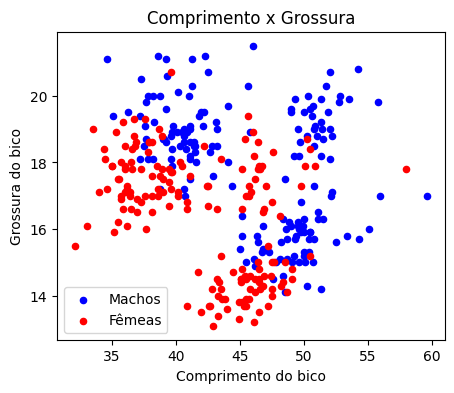

In [143]:
ax1 = penguins_2[penguins_2["sex"] == "Male"].plot(
    x = "bill_length_mm",
    y = "bill_depth_mm",
    kind = "scatter",
    color = "blue",
    label = "Machos",
    figsize = (5,4)
)

penguins_2[penguins_2["sex"] == "Female"].plot(
    x = "bill_length_mm", 
    y = "bill_depth_mm",
    kind = "scatter", 
    title = "Comprimento x Grossura",
    color = "red", 
    label = "Fêmeas",
    ax = ax1,
    xlabel = "Comprimento do bico",
    ylabel = "Grossura do bico" 
)

In [130]:
import matplotlib.pyplot as plt 

Text(0.5, 1.0, 'Comprimento x Grossura do bico ')

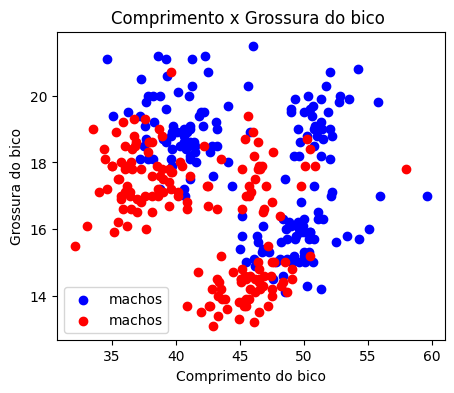

In [142]:
fig, ax = plt.subplots(figsize= (5,4))

penguins_machos = penguins_2.query("sex == 'Male'")
penguins_femea = penguins_2.query("sex == 'Female'")

ax.scatter(penguins_machos["bill_length_mm"], penguins_machos["bill_depth_mm"], color= "blue", label = "machos")
ax.scatter(penguins_femea["bill_length_mm"], penguins_femea["bill_depth_mm"], color= "red", label = "machos")


ax.set_xlabel("Comprimento do bico")
ax.set_ylabel("Grossura do bico")

ax.legend() 

ax.set_title("Comprimento x Grossura do bico ")

In [136]:
ax

<Axes: >

In [145]:
# qual o percentual de macho/femea em cada ilha 

In [150]:
contagem_sex_ilha = penguins_2.groupby(["island", "sex"]).size().reset_index()
contagem_sex_ilha.rename(columns = {0: "quantidade"}, inplace = True)

In [151]:
contagem_sex_ilha

,island,sex,quantidade
0,Biscoe,Female,80
1,Biscoe,Male,83
2,Dream,Female,61
3,Dream,Male,62
4,Torgersen,Female,24
5,Torgersen,Male,23


In [155]:
ilha_contagem_total = penguins_2["island"].value_counts().reset_index()
ilha_contagem_total.rename(columns = {"count": "total"}, inplace = True)

In [156]:
ilha_contagem_total

,island,total
0,Biscoe,163
1,Dream,123
2,Torgersen,47


In [161]:
contagem_final = contagem_sex_ilha.merge(ilha_contagem_total, on = "island", how = "left")
contagem_final


,island,sex,quantidade,total
0,Biscoe,Female,80,163
1,Biscoe,Male,83,163
2,Dream,Female,61,123
3,Dream,Male,62,123
4,Torgersen,Female,24,47
5,Torgersen,Male,23,47


In [162]:
contagem_final["percentual"] = (contagem_final["quantidade"]*100 / contagem_final["total"]).round(2)

In [163]:
contagem_final

,island,sex,quantidade,total,percentual
0,Biscoe,Female,80,163,49.08
1,Biscoe,Male,83,163,50.92
2,Dream,Female,61,123,49.59
3,Dream,Male,62,123,50.41
4,Torgersen,Female,24,47,51.06
5,Torgersen,Male,23,47,48.94
